## HW 6

### Import and read audioset

In [10]:
import os
import requests
import zipfile

url = "https://github.com/karoldvl/ESC-50/archive/master.zip"
zip_file_path = "ESC-50-master.zip"
download_path = "./ESC-50-master/"

if not os.path.exists(download_path):
    response = requests.get(url) 
    
    with open(zip_file_path, 'wb') as f:
        f.write(response.content)
        
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(download_path)
    os.remove(zip_file_path)

In [11]:
import pandas as pd

df_file_path = os.path.join(download_path, "ESC-50-master/meta", "esc50.csv")
df = pd.read_csv(df_file_path)
df.head(5)

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [12]:
# Get two categories
filtered_df = df[df["category"].isin(["dog", "chirping_birds"])]
filtered_df.shape

(80, 7)

In [28]:
import librosa

#  DOG
audio_dog = os.path.join(download_path, "ESC-50-master/audio", "1-59513-A-0.wav")
y_dog, sr_dog = librosa.load(audio_dog, sr=None)

print(f"Dog path: {audio_dog}")
print(f"Len Dog: {len(y_dog)}")
print(f"Frequency Dog: {sr_dog}")

#  BIRD
audio_bird = os.path.join(download_path, "ESC-50-master/audio", "1-100038-A-14.wav")
y_bird, sr_bird = librosa.load(audio_bird, sr=None)

print(f"Bird path: {audio_bird}")
print(f"Len Bird: {len(y_bird)}")
print(f"Frequency Bird: {sr_bird}")

Dog path: ./ESC-50-master/ESC-50-master/audio/1-59513-A-0.wav
Len Dog: 220500
Frequency Dog: 44100
Bird path: ./ESC-50-master/ESC-50-master/audio/1-100038-A-14.wav
Len Bird: 220500
Frequency Bird: 44100


In [16]:
from IPython.display import Audio

Audio(audio_dog)

In [17]:
Audio(audio_bird)

### Spectogram, Pooling, Flaten

In [18]:
import numpy as np

#  Spectogram func
def spectrogram(samples, sample_rate, stride_ms = 10.0,
                          window_ms = 20.0, max_freq = None, eps = 1e-14):

    stride_size = int(0.001 * sample_rate * stride_ms)
    window_size = int(0.001 * sample_rate * window_ms)

    # Extract strided windows
    truncate_size = (len(samples) - window_size) % stride_size
    samples = samples[:len(samples) - truncate_size]
    nshape = (window_size, (len(samples) - window_size) // stride_size + 1)
    nstrides = (samples.strides[0], samples.strides[0] * stride_size)
    windows = np.lib.stride_tricks.as_strided(samples,
                                          shape = nshape, strides = nstrides)

    assert np.all(windows[:, 1] == samples[stride_size:(stride_size + window_size)])

    # Window weighting, squared Fast Fourier Transform (fft), scaling
    weighting = np.hanning(window_size)[:, None]

    fft = np.fft.rfft(windows * weighting, axis=0)
    fft = np.absolute(fft)
    fft = fft**2

    scale = np.sum(weighting**2) * sample_rate
    fft[1:-1, :] *= (2.0 / scale)
    fft[(0, -1), :] /= scale

    # Prepare fft frequency list
    freqs = float(sample_rate) / window_size * np.arange(fft.shape[0])

    # Compute spectrogram feature
    # ind = np.where(freqs <= max_freq)[0][-1] + 1
    specgram = np.log(fft[:, :] + eps)
    return specgram

In [19]:
# Pooling func
def pooling_audio(mat, ksize, method="max", pad=False):
    m, n = mat.shape[:2]
    ky, kx = ksize
    _ceil = lambda x, y: int(np.ceil(x / float(y)))

    if pad:
        ny = _ceil(m, ky)
        nx = _ceil(n, kx)
        size = (ny * ky, nx * kx) + mat.shape[2:]
        mat_pad = np.full(size, np.nan)
        mat_pad[:m, :n, ...] = mat
    else:
        ny = m // ky
        nx = n // kx
        mat_pad = mat[: ny * ky, : nx * kx, ...]

    new_shape = (ny, ky, nx, kx) + mat.shape[2:]

    if method == "max":
        result = np.nanmax(mat_pad.reshape(new_shape), axis=(1, 3))
    else:
        result = np.nanmean(mat_pad.reshape(new_shape), axis=(1, 3))

    return result



In [20]:
# For saving results
X_features = []
y_true_labels = []

# Processing 80 files: Spectogram -> Pooling -> Vector
for index, row in filtered_df.iterrows():
    file_path = os.path.join(download_path, "ESC-50-master/audio", row["filename"])
    y, sr = librosa.load(file_path, sr=None)

    # Spectogram
    spec = spectrogram(samples=y, sample_rate=sr)

    # Pooling
    pooled_spec = pooling_audio(spec, ksize=(10, 10), method="max", pad=True)

    # Flaten to vector 
    feature_vector = pooled_spec.flatten()

    X_features.append(feature_vector)
    y_true_labels.append(row["category"])

# Final matrix for  sklearn
X = np.array(X_features)
y_true = np.array(y_true_labels)

print(f"Final matrix X: {X.shape}")

Final matrix X: (80, 2250)


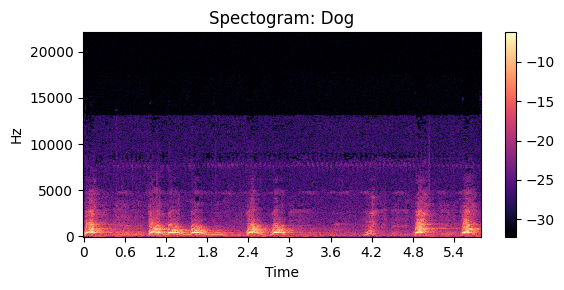

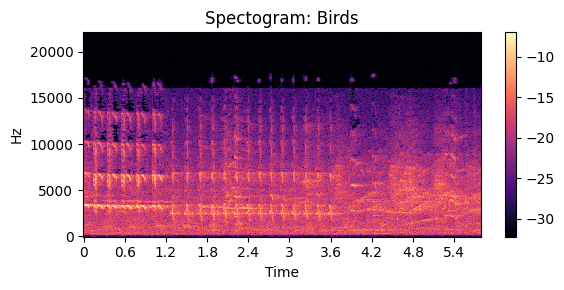

In [ ]:
import matplotlib.pyplot as plt

def show_spec(sig, sr, title):
    spec = spectrogram(sig, sr)
    plt.figure(figsize=(6, 3))
    librosa.display.specshow(spec, sr=sr, x_axis='time', y_axis='linear')
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

# Dog sound
y_dog, sr_dog = librosa.load('./ESC-50-master/ESC-50-master/audio/1-59513-A-0.wav', sr=None)

# Bird sound
y_bird, sr_bird = librosa.load('./ESC-50-master/ESC-50-master/audio/1-100038-A-14.wav', sr=None)

#  Show spectograms
show_spec(y_dog, sr_dog, "Spectogram: Dog")
show_spec(y_bird, sr_bird, "Spectogram: Birds")

#### Spectrogram Analysis Conclusion

**Dog:** 
 The highest energy spikes (yellow areas) are concentrated in the lower frequencies(until 0-5kHz), which is characteristic of a bass-heavy sound. 

**Bird:** 
  The energy is spread across the spectrum, with some of the highest intensity peaks reaching above 12-14 kHz, clearly representing a complex, high-frequency sound source.

### Clustering

In [21]:
from sklearn.cluster import SpectralClustering
import pandas as pd

#  Clustering
model = SpectralClustering(n_clusters=2,affinity='nearest_neighbors', random_state=42)
predicted_clusters = model.fit_predict(X)

# Add results to df 
filtered_df['cluster'] = predicted_clusters
filtered_df


,filename,fold,target,category,esc10,src_file,take,cluster
0,1-100032-A-0.wav,1,0,dog,True,100032,A,1
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A,0
14,1-110389-A-0.wav,1,0,dog,True,110389,A,1
157,1-30226-A-0.wav,1,0,dog,True,30226,A,1
158,1-30344-A-0.wav,1,0,dog,True,30344,A,1
...,...,...,...,...,...,...,...,...
1919,5-243450-A-14.wav,5,14,chirping_birds,False,243450,A,0
1920,5-243459-A-14.wav,5,14,chirping_birds,False,243459,A,0
1921,5-243459-B-14.wav,5,14,chirping_birds,False,243459,B,0
1972,5-257839-A-14.wav,5,14,chirping_birds,False,257839,A,0


In [22]:
print("Clustering results::")
result_table = pd.crosstab(filtered_df['category'], filtered_df['cluster'])
print(result_table)

Clustering results::
cluster          0   1
category              
chirping_birds  33   7
dog             10  30


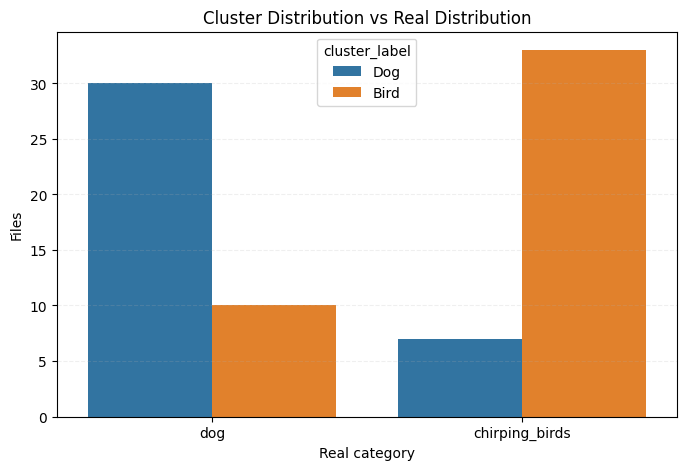

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

#  From Crosstab create cluster labels and add to df
cluster_labels = {1: "Dog", 0: "Bird"}
filtered_df["cluster_label"] = filtered_df["cluster"].map(cluster_labels)

#  Plot to see the real vs cluster
plt.figure(figsize=(8, 5))
sns.countplot(data=filtered_df, x="category", hue="cluster_label", palette="tab10")
plt.title("Cluster Distribution vs Real Distribution")
plt.xlabel("Real category")
plt.ylabel("Files")
plt.grid(axis="y", linestyle="--", alpha=0.2)
plt.show()

### Conslusion

Since a raw audio signal is not informative for ML models due to its high dimensionality and reliance on the time domain, applying the Fourier transform is essential to extract the key signal representation — the spectrogram. 

The pooling operation creates compact, time-invariant feature vectors. This allows the clustering algorithm to separate the sounds based on their unique frequency patterns rather than their raw temporal amplitude.